In [1]:
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import t
from sklearn.utils import resample
# ML classes
from dataHandler import Config, MetadataHandler, OligosHandler, FeatureManager
from plots_helpers import *

import argparse

# basics
import time

from pathlib import Path
import re
from joblib import Parallel, delayed
import pandas as pd
import numpy as np
from typing import Optional, Tuple, List, Dict, Union
import joblib

# Plots
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.gridspec import GridSpec

#ML
from xgboost import XGBClassifier
import shap

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import make_scorer, roc_curve, auc
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_predict, cross_val_score, LeaveOneOut, StratifiedKFold, KFold,permutation_test_score
from sklearn.feature_selection import mutual_info_classif, SelectKBest, VarianceThreshold, SelectFromModel, SelectPercentile
from sklearn import set_config
set_config(transform_output = "pandas")
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [2]:
def search_best_model(estimator, param_grid, X_train, y_train, n_splits=5, n_iter=30, random_state=420, n_jobs = 1):
    # Create a custom scorer using C-index
    cv_inner = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    search = BayesSearchCV(estimator, search_spaces=param_grid,
                                 cv=cv_inner,
                                 n_iter=n_iter,
                                 scoring='roc_auc',
                                 refit=True,
                                 random_state=random_state,
                                 n_jobs=n_jobs)

    search.fit(X_train, y_train)

    return search.best_estimator_

def calculate_mean_std_ci_tpr_auc(auc_list, tpr_list, mean_fpr, bootstrap=True):
        """
        Calculate mean FPR, mean TPR, and std TPR for ROC curves.
        """
        # Aggregate TPRs
        tprs = np.array(tpr_list)
        mean_tpr = tprs.mean(axis=0)
        mean_tpr[-1] = 1.0  # Ensure curve ends at (1, 1)
        std_tpr = tprs.std(axis=0)  # ddof=1

        se = std_tpr * 1.96 if bootstrap else std_tpr
        tprs_lower = np.maximum(mean_tpr - se, 0)
        tprs_upper = np.minimum(mean_tpr + se, 1)

        # Aggregate AUCs
        aucs = np.array(auc_list)
        auc_mean = aucs.mean()
        auc_std = aucs.std()

        if bootstrap:
            auc_ci_lower = np.percentile(aucs, 2.5)
            auc_ci_upper = np.percentile(aucs, 97.5)
            roc_metrics = {
                'boot_mean_fpr': mean_fpr,
                'boot_mean_tpr': mean_tpr,
                'boot_std_tpr': std_tpr,
                'boot_tprs_upper': tprs_upper,
                'boot_tprs_lower': tprs_lower,
                'boot_auc_mean': auc_mean,
                'boot_auc_std': auc_std,
                'boot_auc_ci_lower': auc_ci_lower,
                'boot_auc_ci_upper': auc_ci_upper
            }
            return roc_metrics
        else:
            t_value = t.ppf(0.975, len(aucs) - 1)
            se = t_value * (auc_std / np.sqrt(len(aucs)))
            auc_ci_lower = np.maximum(auc_mean - se, 0)  # 95% CI lower
            auc_ci_upper = np.minimum(auc_mean + se, 1)  # 95% CI upper
            roc_metrics = {
                'fpr': mean_fpr,
                'tpr': mean_tpr,
                'std_tpr': std_tpr,
                'tprs_upper': tprs_upper,
                'tprs_lower': tprs_lower,
                'auc': auc_mean,
                'auc_std': auc_std,
                'auc_ci_lower': auc_ci_lower,
                'auc_ci_upper': auc_ci_upper}

            return roc_metrics

def bootstrap_auc(mean_fpr=None, estimator=None, X=None, y_true=None, y_pred=None, n_bootstraps = 200, random_state=420):
        tpr_bootstraps = []
        auc_bootstraps = []

        if mean_fpr is None:
            mean_fpr = np.linspace(0, 1, 100)  # Define default mean_fpr here

        for i in range(n_bootstraps):
            if estimator is not None and X is not None and y_true is not None:
                X_resampled, y_resampled = resample(X, y_true, stratify=y_true, random_state=random_state + i)
                y_pred_resampled = estimator.predict_proba(X_resampled)[:, 1]
            elif y_pred is not None and y_true is not None:
                y_resampled, y_pred_resampled = resample(y_true, y_pred, stratify=y_true,
                                                         random_state=random_state + i)
            else:
                raise ValueError("Missing arguments. Estimator 'estimator', features 'X' and their true target 'y_true' must be provided for bootstrapping auc for test data."
                                 "For loocv, true target 'y_true' and predictions 'y_pred' must be provided.")

            interp_tpr, auc_value = compute_interp_tpr_auc(y_resampled, y_pred_resampled, mean_fpr)
            tpr_bootstraps.append(interp_tpr)
            auc_bootstraps.append(auc_value)

        roc_metrics = calculate_mean_std_ci_tpr_auc(auc_bootstraps, tpr_bootstraps, mean_fpr, bootstrap = True)

        return roc_metrics

def compute_interp_tpr_auc(y_true, y_pred_proba, mean_fpr):
        # Compute FPR and TPR
        fpr, tpr, _ = roc_curve(y_true, y_pred_proba)

        # Interpolate TPR to the common mean FPR grid
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0  # Ensure the curve starts at (0, 0)

        # Compute AUC
        auc_value = auc(fpr, tpr)

        return interp_tpr, auc_value

def nested_cv_single(train_idx, valid_idx, X_train, y_train, pipeline = None,
                     param_grid = None, n_splits = 5, n_iter = 30,
                     random_state = 420, n_jobs = -1):

    set_config(transform_output = "pandas")
    mean_fpr = np.linspace(0, 1, 100)  # Define default mean_fpr here

    X_train_fold, X_valid_fold = X_train.iloc[train_idx], X_train.iloc[valid_idx]
    y_train_fold, y_valid_fold = y_train.iloc[train_idx], y_train.iloc[valid_idx]
    if pipeline is None:
        params = {'objective': 'binary:logistic', 'eval_metric': 'auc',
                  'random_state': random_state, 'n_jobs': -1}
        # Build the pipeline for this fold.
        pipeline = Pipeline([
            ('variance_removal', VarianceThreshold(threshold=0.0)),
            ('feature_selection', SelectPercentile(score_func=mutual_info_classif, percentile=30)),
            ('classifier', XGBClassifier(**params))
        ])

    # Perform hyperparameter tuning if param_grid is provided.
    if param_grid is not None:
        # Use your search_best_model function or similar with BayesSearchCV
        best_estimator = search_best_model(pipeline, param_grid, X_train_fold, y_train_fold,
                                           n_splits=n_splits, n_iter=n_iter, random_state=random_state, n_jobs=n_jobs)
    else:
        best_estimator = pipeline
        best_estimator.fit(X_train_fold, y_train_fold)

    # Predict risk scores on the validation fold
    scores_fold = best_estimator.predict_proba(X_valid_fold)[:, 1]
    interp_tpr, auc_value = compute_interp_tpr_auc(y_valid_fold, scores_fold, mean_fpr)

    # Transform validation data for SHAP computation
    if len(best_estimator) > 1:
        try:
            X_valid_fold = best_estimator[:-1].transform(X_valid_fold)
        except Exception as e:
            logger.error(f"Error transforming validation data in fold: {e}")
            return None

    # Compute SHAP values using the regressor (last step)
    explainer = shap.TreeExplainer(best_estimator[-1])
    shap_values_fold = explainer.shap_values(X_valid_fold)
    shap_values_fold_df = pd.DataFrame(shap_values_fold, index=X_valid_fold.index, columns=X_valid_fold.columns)

    return valid_idx, scores_fold, shap_values_fold_df, best_estimator, interp_tpr, auc_value


def nested_cv(
        X_train: pd.DataFrame,
        y_train: pd.Series,
        pipeline: Optional[Pipeline] = None,
        param_grid: Optional[Dict] = None,
        n_splits: int = 10,
        n_splits_inner: int = 5,
        n_iter: int = 30,
        random_state: int = 420,
        n_jobs: int = 1,
        n_jobs_inner: int = -1
) -> Tuple[List[Pipeline], pd.DataFrame, pd.Series, List[np.ndarray], List[Dict]]:
    """
    Perform nested cross-validation to tune hyperparameters and feature selection,
    and aggregate SHAP values and risk scores for each outer fold.

    For each outer fold:
      - Split data into training and validation sets.
      - Run hyperparameter tuning (BayesSearchCV) on the inner folds (if param_grid is provided)
        to select the best estimator.
      - Use the best estimator to predict risk scores on the validation set.
      - Compute SHAP values on the validation set. Note: because the pipeline's
        feature selection step may select a different subset of features per fold,
        the returned SHAP values DataFrame may have different columns.
      - Store the risk scores and SHAP values (with sample indices).

    Parameters
    ----------
    X_train : pd.DataFrame
        Feature matrix for training.
    y_train : pd.Series
        Classes for training samples.
    pipeline : dict, optional
        Default pipeline for hyperparameter tuning. If None, default parameters are used.
    param_grid : dict, optional
        Hyperparameter grid to search over. If None, no hyperparameter tuning is performed.
    n_splits : int, default 10
        Number of outer CV splits.
    n_splits_inner : int, default 5
        Number of inner CV splits.
    n_iter : int, default 30
        Number of iterations for Bayesian optimization.
    random_state : int, default 420
        Seed for reproducibility.
    n_jobs : int, default -1
        Number of parallel jobs to run in the outer CV (default is all cores -1).
    n_jobs_inner : int, default 1
        Number of parallel jobs to run in the inner CV (default is 1).
    Returns
    -------
    model_list : List[Pipeline]
        List of best estimators (one per fold).
    shap_values : pd.DataFrame
        DataFrame concatenating SHAP values from all folds, indexed by sample.
    scores : pd.Series
        Series of predicted scores from all folds, indexed by sample.
    validation_indices : List[np.ndarray]
        validation indices for each outer fold.
    roc_metrics : List[Dict]
        List of dictionaries containing ROC metrics for each outer fold.
    """
    #outer_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    outer_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    # Run the outer folds in parallel.
    fold_results = Parallel(n_jobs=n_jobs)(
        delayed(nested_cv_single)(
            train_idx, valid_idx, X_train, y_train,
            pipeline = pipeline, param_grid = param_grid,
            n_splits = n_splits_inner, n_iter = n_iter,
            random_state = random_state, n_jobs = n_jobs_inner) for train_idx, valid_idx in outer_cv.split(X_train, y_train))
    # Filter out any folds that returned None (e.g., due to transformation errors).
    fold_results = [result for result in fold_results if result is not None]

    # Initialize master containers.
    validation_indices = []
    model_list = []
    auc_list, tpr_list = [], []
    mean_fpr = np.linspace(0, 1, 100)  # Define default mean_fpr here
    scores = pd.Series(index=X_train.index, name='score')
    shap_values = pd.DataFrame(0.0, index=X_train.index, columns=X_train.columns)

    # Aggregate results from each fold.
    i=0
    #    return valid_idx, scores_fold, shap_values_fold_df, best_estimator, interp_tpr, auc_value
    for valid_idx, fold_scores, fold_shap_df, model,  interp_tpr, auc_value in fold_results:
        model_list.append(model)
        # Assign scores for the validation fold.
        scores.iloc[valid_idx] = fold_scores
        # Update master SHAP values. Since folds are disjoint, direct assignment works.
        shap_values.loc[fold_shap_df.index, fold_shap_df.columns] = fold_shap_df

        y_valid_fold = y_train.iloc[valid_idx]

        validation_indices.append(valid_idx)
        auc_list.append(auc_value)
        tpr_list.append(interp_tpr)
        i=i+1

    roc_metrics = bootstrap_auc(mean_fpr=mean_fpr, y_true=y_train, y_pred=scores.values, n_bootstraps = 200, random_state=420)
    kfold_metrics = calculate_mean_std_ci_tpr_auc(auc_list, tpr_list, mean_fpr, bootstrap=False)
    roc_metrics.update(kfold_metrics)

    logger.info(f"Mean AUC across folds: {np.mean(auc_list):.4f}")

    return model_list, shap_values, scores, validation_indices, roc_metrics

In [3]:
def plot_roc_curve(roc_metrics, subgroup_name,
                   ax = None,
                   subgroup_color = 'dodgerblue',
                   chance_color = 'black',
                   alpha_ci=0.2, show_legend = True,
                   save_fig = False, set_type = "",
                   suffix_file = None, figures_dir = './', sample_size=None,
                   plot_title = None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5.5,5.5))


    ax.plot(roc_metrics['boot_mean_fpr'], roc_metrics['boot_mean_tpr'], color=subgroup_color, alpha=1.0,
            label=f"{subgroup_name} (AUC={round(roc_metrics['boot_auc_mean'], 3)} [{round(roc_metrics['boot_auc_ci_lower'], 2)}, {round(roc_metrics['boot_auc_ci_upper'], 2)}])", lw=3)
    ax.fill_between(roc_metrics['boot_mean_fpr'], roc_metrics['boot_tprs_lower'], roc_metrics['boot_tprs_upper'], color="dodgerblue", alpha=alpha_ci, label='95% CI (Bootstrapping)')

    if set_type == "trainSet":
        ax.plot(roc_metrics['fpr'], roc_metrics['tpr'], color="black", alpha=1.0,
                label=r"Mean CV (AUC = %0.2f $\pm$ %0.2f)" % (roc_metrics['auc'], roc_metrics['auc_std']), lw=2)
        ax.fill_between(roc_metrics['fpr'], roc_metrics['tprs_lower'], roc_metrics['tprs_upper'], color='gray', alpha=0.3, label=r"Folds Variability ($\pm$ 1 Std)")
    else:
        ax.plot(roc_metrics['fpr'], roc_metrics['tpr'], color="black", alpha=1.0,
                 label=r"AUC = %0.2f " % (roc_metrics['auc']), lw=2)

    ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color=chance_color, label='Random Classifier', alpha=.8)
    if show_legend:
        ax.legend(fontsize=9,loc="lower right")
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_xlabel('False Positive Rate', fontsize=11)

    # Add border to the x and y axes (spines)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.5)

    # Add title to the plot
    if plot_title is not None:
        ax.set_title(plot_title, fontsize=12, weight='bold', pad=11)

    # Remove grid for a clean look
    ax.grid(False)

    # Add ticks on both x and y axes
    ax.tick_params(axis='x', colors='black', size=6, width=1.2)
    ax.tick_params(axis='y', colors='black', size=6, width=1.2)
    ax.xaxis.set_tick_params(which='both', top=False, bottom=True)
    ax.yaxis.set_tick_params(which='both', left=True, right=False)

    # Remove grid for a clean look
    ax.grid(False)

    # Set transparent background
    ax.patch.set_alpha(0.0)
    #ax.set_facecolor("white")

    if save_fig:
        if suffix_file is None:
            suffix_file = config.label_group_tests
        plt.savefig(Path(figures_dir) / f'roc_curve_best_{suffix_file}.png',
                    dpi=300, bbox_inches='tight')
    return ax

def plot_combined_histogram_density(original_auc, permuted_aucs, pvalue = None, group_tests = None, ax = None, set_type="", figures_dir = "./", sample_size=None, estimator_name="",plot_title = None, suffix_file = None, save_fig = False):
    if ax is None:
        fig, ax = plt.subplots() #figsize=(8, 6)

    ax.set_ylabel('Count', fontsize=10)
    ax.set_xlabel('AUC Score', fontsize=10)
    # Add border to the x and y axes (spines)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.5)

    # Add title to the plot
    if plot_title is None:
        if sample_size is not None:
            plot_title = f"{estimator_name}:{set_type} (N={sample_size})\n{' vs '.join(group_tests)}\nDistribution of Permuted AUCs vs Observed AUC\nPermutation Test (p-value = {pvalue:.3f})"
        else:
            plot_title = f"{estimator_name}:{set_type}\n{' vs '.join(group_tests)}\nDistribution of Permuted AUCs vs Observed AUC\nPermutation Test (p-value = {pvalue:.3f})"
    ax.set_title(plot_title, fontsize=12, weight='bold', pad=10)

    # Remove grid for a clean look
    ax.grid(False)
    ax.patch.set_alpha(0.0)

    # Add ticks on both x and y axes
    ax.tick_params(axis='x', colors='black', size=5, width=1.2)
    ax.tick_params(axis='y', colors='black', size=5, width=1.2)
    ax.xaxis.set_tick_params(which='both', top=False, bottom=True)
    ax.yaxis.set_tick_params(which='both', left=True, right=False)
    # Add border to the x and y axes (spines)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.5)

    ax.axvline(original_auc, color='dodgerblue', linestyle='dashed', linewidth=2, label='Observed AUC')
    sns.histplot(permuted_aucs, bins=30, kde=True, color='gray', alpha=0.4, label='Permuted AUCs', ax=ax)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)
    if save_fig:
        if suffix_file is not None:
            suffix_file = set_type+estimator_name+"_" + "-".join(group_tests)
        plt.savefig(Path(figures_dir)/ f'Distribution_PermutationTest_{suffix_file}', dpi=300, bbox_inches='tight')

    return ax

def plot_permuted_aucs_boxplot(original_auc, permuted_aucs,  pvalue = None, group_tests = None, ax = None, set_type="", figures_dir = "./", sample_size=None,
                                    estimator_name="", plot_title = None, suffix_file = None, save_fig = False):
    if ax is None:
        fig, ax = plt.subplots() #figsize=(8, 6)

    ax.set_ylabel('AUC Score', fontsize=10)
    #ax.set_xlabel('Permuted AUCs', fontsize=9)
    # Add border to the x and y axes (spines)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.5)

    # Add title to the plot
    if plot_title is None:
        if sample_size is not None:
            plot_title = f"{estimator_name}:{set_type} (N={sample_size})\n{' vs '.join(group_tests)}\nPermuted AUCs vs Observed AUC\nPermutation Test (p-value = {pvalue:.3f})"
        else:
            plot_title = f"{estimator_name}:{set_type}\n{' vs '.join(group_tests)}\nPermuted AUCs vs Observed AUC\nPermutation Test (p-value = {pvalue:.3f})"
    ax.set_title(plot_title, fontsize=12, weight='bold', pad=10)

    # Remove grid for a clean look
    ax.grid(False)
    ax.patch.set_alpha(0.0)

    # Add ticks on both x and y axes
    ax.tick_params(axis='x', colors='black', size=5, width=1.2)
    ax.tick_params(axis='y', colors='black', size=5, width=1.2)
    ax.xaxis.set_tick_params(which='both', top=False, bottom=True)
    ax.yaxis.set_tick_params(which='both', left=True, right=False)
    # Add border to the x and y axes (spines)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.5)

    plt.boxplot(permuted_aucs, vert=True, patch_artist=True, boxprops=dict(facecolor='gray', alpha=0.5), labels=['Permuted AUCs'])
    plt.xticks(fontsize=10)  # Adjust the font size as needed
    ax.set_ylim(0, 1)
    # Get the x position of the boxplot
    x_positions = [1]  # Since we have only one boxplot, its x-position is 1
    box_width = 0.1  # Adjust this value to change the width of the line
    xmin = x_positions[0] - box_width
    xmax = x_positions[0] + box_width
    ax.hlines(original_auc, xmin=xmin, xmax=xmax, color='dodgerblue', linestyle='dashed', linewidth=2, label='Observed AUC')
    #plt.axhline(original_auc, color='dodgerblue', linestyle='dashed', linewidth=2, label='Original AUC')

    ax.legend(fontsize=8)
    if save_fig:
        if suffix_file is not None:
            suffix_file = set_type+estimator_name+"_" + "-".join(group_tests)
        plt.savefig(Path(figures_dir)/ f'Distribution_PermutationTest_{suffix_file}', dpi=300, bbox_inches='tight')

    return ax


In [4]:
def make_pipeline(peptide_cols, demog_cols, estimator):
    """
    Build a pipeline which:
      - on peptide_cols: does variance threshold + SelectPercentile(mutual_info)
      - on demog_cols : just passes them through untouched
      - then fits whatever `estimator` you give it
    """
    transformers = []
    if peptide_cols:
        transformers.append((
            "peptides",
            Pipeline([
                ("variance_removal", VarianceThreshold(threshold=0.0)),
                ("feature_selection", SelectPercentile(mutual_info_classif, percentile=20)),
            ]),
            peptide_cols
        ))
    if demog_cols:
        transformers.append(
            ("demographics", "passthrough", demog_cols)
        )

    preprocessor = ColumnTransformer(
        transformers,
        remainder="drop",   # drop anything not in peptide_cols or demog_cols
        verbose_feature_names_out=False   # <— disable automatic "peptides__…" prefixes
    )

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("estimator",     estimator)
    ])
    return pipe


def align_features(X_train, X_ext):
    """Align features between training and external test sets."""
    common_features = list(set(X_train.columns).intersection(X_ext.columns))
    if common_features:
        X_train = X_train[common_features]
        X_ext = X_ext[common_features]
        return X_train, X_ext
    else:
        raise ValueError(f"Training and External set shared no common features")

def _compute_roc_metrics_test(estimator, X_test, y_test, predicted_probs_test):
    """Compute ROC metrics for the test set."""
    fpr, tpr, _ = roc_curve(y_test, predicted_probs_test)
    roc_metrics = bootstrap_auc(estimator=estimator, X=X_test, y_true=y_test)
    roc_metrics.update({"fpr": fpr, "tpr": tpr, "auc": auc(fpr, tpr), "auc_std": None})

    return roc_metrics

def train_and_validate_model(X_train: pd.DataFrame, y_train: pd.Series,
                             X_test: pd.DataFrame, y_test: pd.Series,
                             pipeline: Optional[Pipeline] = None,
                             param_grid: Optional[Dict] = None,
                             n_splits: int = 10,
                             n_iter: int = 30,
                             random_state: int = 420,
                             n_jobs: int = -1,
                             get_only_model: bool = False)-> None | Pipeline | tuple[Pipeline, pd.DataFrame, pd.Series, Dict]:

    """
    Parameters
    ----------
    X_train : pd.DataFrame
        Feature matrix for training.
    y_train : pd.Series
        Target variable for training.
    X_test : pd.DataFrame
        Feature matrix for testing.
    y_test : pd.Series
        Target variable for testing.
    pipeline : dict, optional
        Default pipeline for hyperparameter tuning. If None, default parameters are used.
    param_grid : dict, optional
        Hyperparameter grid to search over. If None, no hyperparameter tuning is performed.
    n_splits : int, default 10
        Number of outer CV splits.
    n_iter : int, default 30
        Number of iterations for Bayesian optimization.
    random_state : int, default 420
        Seed for reproducibility.
    n_jobs : int, default -1
        Number of parallel jobs to run in the outer CV (default is all cores -1).
    get_only_model : bool, default False
        return only the fitted model
    Returns
    -------
    best_estimator : Pipeline
        best estimator
    shap_values_df : pd.DataFrame
        DataFrame SHAP values, indexed by sample.
    scores : pd.Series
        Series of predicted probabilities per class, indexed by sample.
    roc_metrics_test : Dict
        Dict containing ROC metrics for testing set.
    """

    set_config(transform_output = "pandas")
    X_train, X_test = align_features(X_train, X_test)
    shap_values_df = pd.DataFrame(0.0, index=X_test.index, columns=X_test.columns)

    if pipeline is None:
        params = {'objective': 'binary:logistic', 'eval_metric': 'auc',
                  'random_state': random_state, 'n_jobs': -1}

        ALL_DEMOG = {"Sex", "Age"}
        peptide_cols = [c for c in X_train.columns if c not in ALL_DEMOG]
        demog_cols = [c for c in X_train.columns if c in ALL_DEMOG]

        # Build the pipeline
        pipeline = make_pipeline(peptide_cols=peptide_cols, demog_cols=demog_cols, estimator=XGBClassifier(**params))

    # Perform hyperparameter tuning if param_grid is provided.
    if param_grid is not None:
        # Use your search_best_model function or similar with BayesSearchCV
        best_estimator = search_best_model(pipeline, param_grid, X_train, y_train,
                                           n_splits=n_splits, n_iter=n_iter, random_state=random_state, n_jobs=n_jobs)
    else:
        best_estimator = pipeline
        best_estimator.fit(X_train, y_train)

    if get_only_model:
        return best_estimator

        # Predict risk scores on the validation fold
    scores = best_estimator.predict_proba(X_test)[:, 1]
    scores = pd.Series(scores, index=X_test.index, name='Score')


    # Transform validation data for SHAP computation
    if len(best_estimator) > 1:
        try:
            X_test = best_estimator[:-1].transform(X_test)
            #X_test.columns = X_test.columns.str.replace(r'^[^_]+__', '', regex=True)
        except Exception as e:
            logger.error(f"Error transforming validation data: {e}")
            return None

    roc_metrics_test = _compute_roc_metrics_test(best_estimator[-1], X_test, y_test, scores)


    # Compute SHAP values using the regressor (last step)
    explainer = shap.TreeExplainer(best_estimator[-1])
    shap_values = explainer.shap_values(X_test)
    shap_values = pd.DataFrame(shap_values, index=X_test.index, columns=X_test.columns)
    shap_values_df.loc[shap_values.index, shap_values.columns] = shap_values

    logger.info(f"AUC in testing set: {roc_metrics_test.get('auc'):.4f}")

    # # Create predictions DataFrame
    # predictions_test = _create_binary_class_predictions_df("XGBClassifier",
    #                                                             roc_metrics_test.get("auc"),
    #                                                             roc_metrics_test.get("auc_std"))

    return best_estimator, shap_values_df, scores, roc_metrics_test

In [11]:
#config_file = "/home/creyna/Vogl-lab_Projects_git/HCC/Metadata/config_survival_trainTest.yaml"
config_file = "/home/creyna/Vogl-lab_Projects_git/HCC/Metadata/config_control_hcc.yaml"
config = Config(config_file)
metadata_handler = MetadataHandler(config)
#oligos_handler = OligosHandler(config)
oligos_handler = OligosHandler(config) #, data_type=config.data_types[0])
feature_manager = FeatureManager(config, metadata_handler, oligos_handler,
                                 subgroup = 'all',
                                 with_oligos=True,
                                 with_additional_features = False,
                                 filter_by_entropy=False,
                                 prevalence_threshold_min=0,
                                 prevalence_threshold_max=100)
X_train, y_train = feature_manager.get_features_target()
X_train.shape

(180, 6697)

In [13]:
config_file = "/home/creyna/Vogl-lab_Projects_git/HCC/Metadata/config_standard.yaml"
config = Config(config_file)
#config.set_group_tests(["Controls", "HCC"])

In [14]:
config.filters_metadata = {"group_test":"Controls"}

In [112]:
config.set_filters_metadata({"group_test":"Controls"})

In [114]:
config.set_filters_metadata({"treatment":"ICI", "Centre":"Vienna"})

In [116]:
config.set_filters_metadata({"treatment":"ICI", "Centre":"Hamburg"})

In [ ]:
config.set_filters_metadata({"treatment":"TKI"})

In [19]:
config.set_filters_metadata({"treatment":"ICI"})

In [6]:
config.set_filters_metadata({'group_test': ['Controls', 'HCC']})

In [7]:
config.filters_metadata

{'group_test': ['Controls', 'HCC']}

In [15]:
metadata_handler = MetadataHandler(config)
#oligos_handler = OligosHandler(config)
oligos_handler = OligosHandler(config) #, data_type=config.data_types[0])
feature_manager = FeatureManager(config, metadata_handler, oligos_handler,
                                 subgroup = 'all',
                                 with_oligos=True,
                                 with_additional_features = False,
                                 prevalence_threshold_min=0,
                                 prevalence_threshold_max=100)
X_control, y_control = feature_manager.get_features_target()

In [17]:
X_control.shape

(72, 53566)

In [19]:
config.estimators_info

{'XGBClassifier': {'estimator_class': xgboost.sklearn.XGBClassifier,
  'estimator_kwargs': {'objective': 'binary:logistic',
   'eval_metric': 'auc',
   'random_state': 420,
   'nthread': 1,
   'n_jobs': -1,
   'n_estimators': 150,
   'learning_rate': 0.1,
   'max_depth': 6}}}

In [18]:
config.set_filters_metadata({"treatment":"TKI"})
X_train, y_train = feature_manager.get_features_target()
X_train.shape

(30, 53566)

In [20]:
metadata_handler = MetadataHandler(config)
#oligos_handler = OligosHandler(config)
oligos_handler = OligosHandler(config) #, data_type=config.data_types[0])
feature_manager = FeatureManager(config, metadata_handler, oligos_handler,
                                 subgroup = 'all',
                                 with_oligos=True,
                                 with_additional_features = False,
                                 prevalence_threshold_min=0,
                                 prevalence_threshold_max=100)
X_train, y_train = feature_manager.get_features_target()

In [12]:
config.param_gridcd

{'preprocessor__peptides__feature_selection__percentile': Integer(low=5, high=50, prior='uniform', transform='identity'),
 'estimator__learning_rate': Real(low=0.01, high=0.3, prior='uniform', transform='identity'),
 'estimator__max_depth': Integer(low=3, high=10, prior='uniform', transform='identity'),
 'estimator__subsample': Real(low=0.6, high=1.0, prior='uniform', transform='identity'),
 'estimator__colsample_bytree': Real(low=0.6, high=1.0, prior='uniform', transform='identity'),
 'estimator__reg_lambda': Real(low=0.1, high=10.0, prior='log-uniform', transform='identity'),
 'estimator__n_estimators': Integer(low=50, high=500, prior='uniform', transform='identity')}

In [49]:
# Build the pipeline
params = {'objective': 'binary:logistic', 'eval_metric': 'auc',
                  'random_state': 420, 'n_jobs': -1}

ALL_DEMOG = {"Sex", "Age"}
peptide_cols = [c for c in X_train.columns if c not in ALL_DEMOG]
demog_cols = [c for c in X_train.columns if c in ALL_DEMOG]
pipeline = make_pipeline(peptide_cols=peptide_cols, demog_cols=demog_cols, estimator=XGBClassifier(**params))

param_grid = {
        'preprocessor__peptides__feature_selection__percentile': Integer(2, 50),
        'estimator__learning_rate': Real(0.01, 0.3, prior='uniform'),
        'estimator__max_depth': Integer(3, 10),
        'estimator__subsample': Real(0.6, 1.0, prior='uniform'),
        'estimator__colsample_bytree': Real(0.6, 1.0, prior='uniform'),
        'estimator__reg_lambda': Real(0.1, 10.0, prior='log-uniform'),
        'estimator__n_estimators': Integer(50, 500)
    }

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, train_size=0.8,
                                                    random_state=420, shuffle=True, stratify=y_train)

best_estimator, test_shap_values, scores_test, roc_metrics_test = train_and_validate_model(X_train, y_train,
                                                                                           X_test, y_test,
                                                                                           pipeline=pipeline,
                                                                                           param_grid=param_grid,
                                                                                           n_splits = 10,
                                                                                           n_iter = 50,
                                                                                           random_state = 420,
                                                                                           n_jobs = -1,
                                                                                           get_only_model = False)

INFO:__main__:AUC in testing set: 0.8571


In [89]:
start_time = time.time()

model_list, train_shap_values, scores_train, validation_indices, roc_metrics_train = nested_cv(X_train,
                                                                                y_train,
                                                                                pipeline = pipeline,
                                                                                param_grid=param_grid,
                                                                                n_splits=10, n_splits_inner=5,
                                                                                n_iter=50,
                                                                                random_state=42,
                                                                                n_jobs = 1, n_jobs_inner = 7)

end_time = time.time()
logger.info(f"Script runtime: {end_time - start_time:.2f} seconds")

    # Save the results as a dictionary
    # Save the results as a dictionary
results = {
        'model_list': model_list,
        'train_shap_values': train_shap_values,
        'scores_train': scores_train,
        'validation_indices_train': validation_indices,
        'roc_metrics_train': roc_metrics_train
    }

joblib.dump(results, f'classif_nestedCV_bestmodel_42.joblib')

INFO:__main__:Mean AUC across folds: 0.7472
INFO:__main__:Script runtime: 7783.10 seconds


['classif_nestedCV_bestmodel_42.joblib']

# Peptides

<Axes: title={'center': 'XGBClassifier - nested CV (10 outer - 5 inner k-fold)\nControls (n=72) vs HCC (n=108)'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

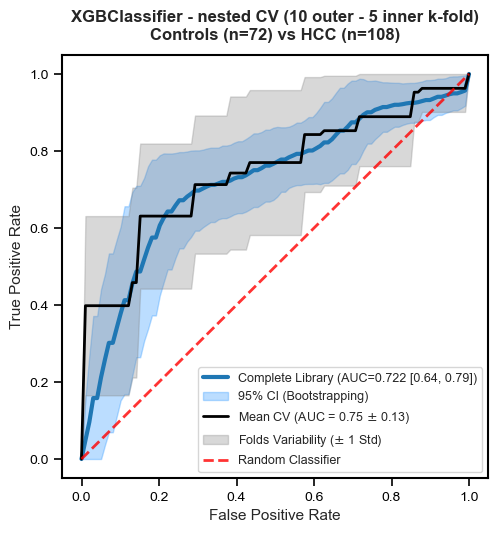

In [19]:
results = joblib.load(f'classif_nestedCV_bestmodel_42.joblib')
subgroup_color = config.subgroups_colors['Complete library']
plot_roc_curve(results['roc_metrics_train'], 'Complete Library',
                   ax = None,
                   subgroup_color = subgroup_color,
                   chance_color = 'red',
                   alpha_ci=0.3, show_legend = True,
                   save_fig = True, set_type = "trainSet",
                   suffix_file = "onlyPeptides", figures_dir = config.figures_dir, sample_size=None,
                   plot_title = "XGBClassifier - nested CV (10 outer - 5 inner k-fold)\nControls (n=72) vs HCC (n=108)")

/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: >

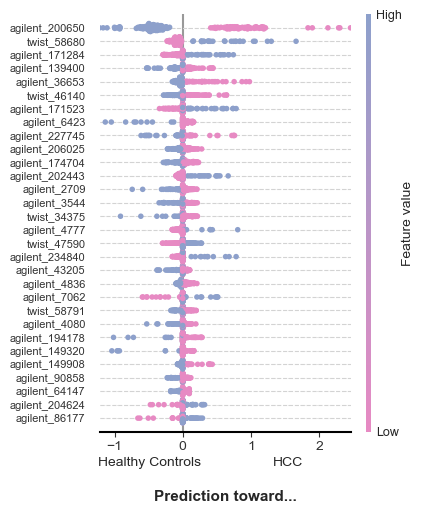

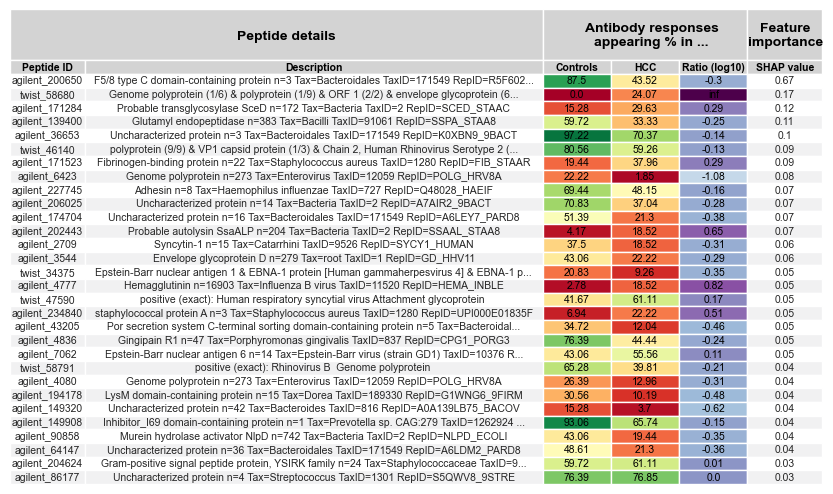

In [16]:
newCmap = LinearSegmentedColormap.from_list("", ['#E78AC3', '#8DA0CB'])  # nonORR-ORR['#E78AC3', '#8DA0CB'])  # Controls - HCC ['#CD8500', '#40E0D0']) nonDCR -DCR ['#FFD92F','#E5C494'])

plot_shap_values(results['train_shap_values'].values, X_train, cmap=newCmap, max_display=30,
                 label_groups = ['Healthy Controls', 'HCC'], suffix_file=f'xgb_Cox-Hazard_trainingSet_classif_Controls_vs_HCC',
                 save_fig = True,  figures_dir = config.figures_dir )

oligos_metadata = oligos_handler.get_oligos_metadata_df()[['Description', 'full name', 'len_seq', 'pos', 'Organism_complete_name']]
y_train.name = config.col_target  # Naming the Series since it currently has no name
feature_importance_train = generate_feature_importance_table(results['train_shap_values'].values, X_train, y_train, oligos_metadata,
                                                             group_tests = config.group_tests, suffix_file=f'classif_Controls_vs_HCC', figures_dir = config.figures_dir)
plot_table_top_features(feature_importance_train,
                        to_select_features = 30,
                        group_tests = config.group_tests,
                        figure_dir = config.figures_dir, suffix_file =f'xgb_Cox-Hazard_trainingSet_classif_Controls_vs_HCC', save_fig = True)

# Peptides + Sex & Age

In [102]:
peptide_cols = [col for col in X_train.columns if col not in ['Sex', 'Age']]
demographic_cols = ['Sex', 'Age']

# Pipeline for peptide features: variance removal and feature selection.
peptide_pipeline = Pipeline([
    ('variance_removal', VarianceThreshold(threshold=0.0)),
    ('feature_selection', SelectPercentile(score_func=mutual_info_classif, percentile=20))
])

# Transformer for demographic features: simply pass them through.
demographic_pipeline = Pipeline([
    # 'passthrough' can be used to leave these columns unchanged.
    ('pass', 'passthrough')
])

# Use ColumnTransformer to apply different pipelines to different sets of columns.
# Alternatively, you can use FeatureUnion if your data is already in a unified DataFrame.
preprocessor = ColumnTransformer(
    transformers=[
        ('peptides', peptide_pipeline, peptide_cols),
        ('demographics', demographic_pipeline, demographic_cols)
    ]
)

# Build the full pipeline.
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(**params, n_jobs=1))
])



param_grid = {
        'preprocessor__peptides__feature_selection__percentile': Integer(5, 50),
        'classifier__learning_rate': Real(0.01, 0.3, prior='uniform'),
        'classifier__max_depth': Integer(3, 10),
        'classifier__subsample': Real(0.6, 1.0, prior='uniform'),
        'classifier__colsample_bytree': Real(0.6, 1.0, prior='uniform'),
        'classifier__reg_lambda': Real(0.1, 10.0, prior='log-uniform'),
        'classifier__n_estimators': Integer(50, 500)
    }

model_list, train_shap_values, scores_train, validation_indices, roc_metrics_train = nested_cv(X_train,
                                                                                y_train,
                                                                                pipeline = pipeline,
                                                                                param_grid=param_grid,
                                                                                n_splits=10, n_splits_inner=5,
                                                                                n_iter=50,
                                                                                random_state=42,
                                                                                n_jobs = 1, n_jobs_inner = -1)

end_time = time.time()
logger.info(f"Script runtime: {end_time - start_time:.2f} seconds")

    # Save the results as a dictionary
    # Save the results as a dictionary
results = {
        'model_list': model_list,
        'train_shap_values': train_shap_values,
        'scores_train': scores_train,
        'validation_indices_train': validation_indices,
        'roc_metrics_train': roc_metrics_train
    }

joblib.dump(results, f'classif_nestedCV_bestmodel_withSex_Age_42.joblib')

INFO:__main__:Mean AUC across folds: 0.7418
INFO:__main__:Script runtime: 18158.41 seconds


['classif_nestedCV_bestmodel_withSex_Age_42.joblib']

<Axes: title={'center': 'XGBClassifier (N=180)\nControls vs HCC\nPeptides + Sex & Age'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

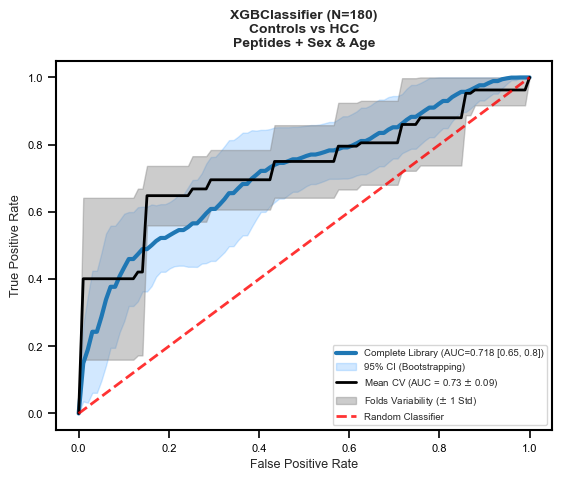

In [101]:
results = joblib.load(f'classif_nestedCV_bestmodel_withSex_Age_5.joblib')
subgroup_color = config.subgroups_colors['Complete library']
plot_roc_curve(results['roc_metrics_train'], 'Complete Library',
                   ax = None,
                   subgroup_color = subgroup_color,
                   chance_color = 'red',
                   alpha_ci=0.2, show_legend = True,
                   save_fig = True, set_type = "trainSet",
                   suffix_file = "peptides_SexAge", figures_dir = config.figures_dir, sample_size=None,
                   plot_title = "XGBClassifier (N=180)\nControls vs HCC\nPeptides + Sex & Age")

# Sex & Age

In [ ]:
# Build the full pipeline.
pipeline = Pipeline([
    ('classifier', XGBClassifier(**params, n_jobs=1))
])



param_grid = {
        'classifier__learning_rate': Real(0.01, 0.3, prior='uniform'),
        'classifier__max_depth': Integer(3, 10),
        'classifier__subsample': Real(0.6, 1.0, prior='uniform'),
        'classifier__colsample_bytree': Real(0.6, 1.0, prior='uniform'),
        'classifier__reg_lambda': Real(0.1, 10.0, prior='log-uniform'),
        'classifier__n_estimators': Integer(50, 500)
    }

model_list, train_shap_values, scores_train, validation_indices, roc_metrics_train = nested_cv(X_train,
                                                                                y_train,
                                                                                pipeline = pipeline,
                                                                                param_grid=param_grid,
                                                                                n_splits=5, n_splits_inner=5,
                                                                                n_iter=10,
                                                                                random_state=42,
                                                                                n_jobs = 1, n_jobs_inner = -1)

end_time = time.time()
logger.info(f"Script runtime: {end_time - start_time:.2f} seconds")

    # Save the results as a dictionary
    # Save the results as a dictionary
results = {
        'model_list': model_list,
        'train_shap_values': train_shap_values,
        'scores_train': scores_train,
        'validation_indices_train': validation_indices,
        'roc_metrics_train': roc_metrics_train
    }

joblib.dump(results, f'classif_nestedCV_bestmodel_withOnlySex_Age_42.joblib')

<Axes: title={'center': 'XGBClassifier (N=180)\nControls vs HCC\nSex & Age'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

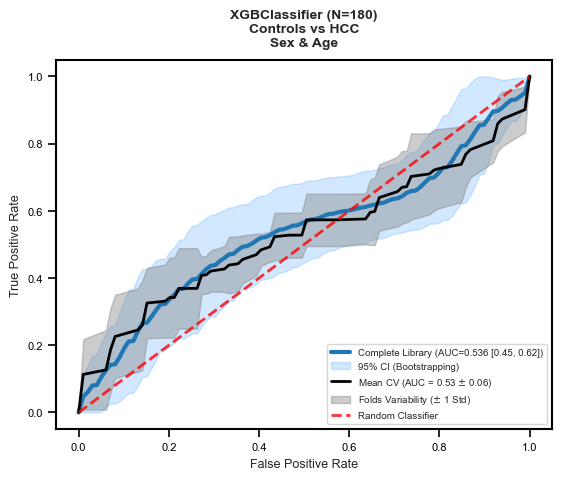

In [64]:
results = joblib.load(f'classif_nestedCV_bestmodel_withOnlySex_Age_42.joblib')
subgroup_color = config.subgroups_colors['Complete library']
plot_roc_curve(results['roc_metrics_train'], 'Complete Library',
                   ax = None,
                   subgroup_color = subgroup_color,
                   chance_color = 'red',
                   alpha_ci=0.2, show_legend = True,
                   save_fig = True, set_type = "trainSet",
                   suffix_file = None, figures_dir = './', sample_size=None,
                   plot_title = "XGBClassifier (N=180)\nControls vs HCC\nSex & Age")

In [46]:
from sklearn.metrics import roc_auc_score
#config_file = "/home/creyna/Vogl-lab_Projects_git/HCC/Metadata/config_survival_trainTest.yaml"
config_file = "/home/creyna/Vogl-lab_Projects_git/HCC/Metadata/config_control_hcc.yaml"
config = Config(config_file)
metadata_handler = MetadataHandler(config)
#oligos_handler = OligosHandler(config)
oligos_handler = OligosHandler(config) #, data_type=config.data_types[0])
feature_manager = FeatureManager(config, metadata_handler, oligos_handler,
                                 subgroup = 'all',
                                 with_oligos=True,
                                 with_additional_features = False,
                                 filter_by_entropy=False,
                                 prevalence_threshold_min=10,
                                 prevalence_threshold_max=100)
X_train, y_train = feature_manager.get_features_target()
X_train.shape

(180, 962)

In [61]:
params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'random_state': 420,
    }

pipeline = Pipeline([
        ('variance_removal', VarianceThreshold(threshold=0.0)),
#        ('feature_selection', SelectPercentile(score_func=mutual_info_classif, percentile=20)),
        ('classifier', XGBClassifier(**params, n_jobs=1))
])

score, permutation_scores, pvalues = permutation_test_score(pipeline, X_train, y_train, scoring="roc_auc", cv=10, n_jobs=10,
                                                            n_permutations=500, random_state=420)

/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_1266262/1467855152.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(permuted_aucs, vert=True, patch_artist=True, boxprops=dict(facecolor='gray', alpha=0.5), labels=['Permuted AUCs'])


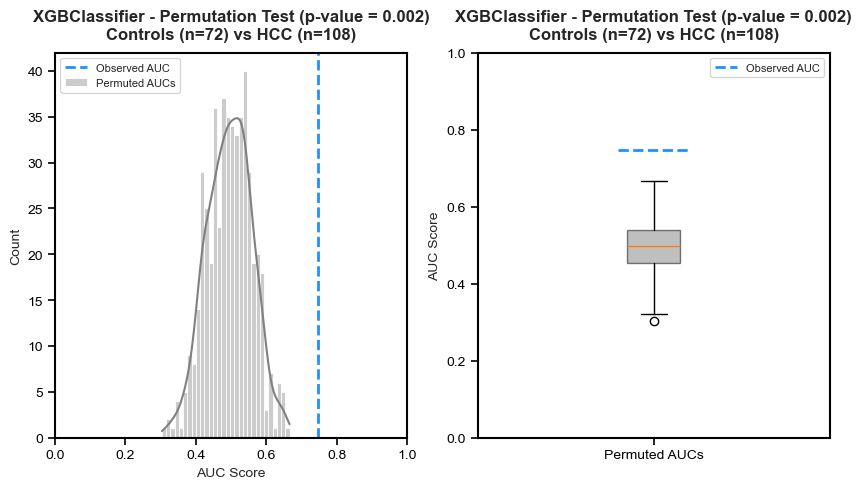

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_combined_histogram_density(original_auc=score, permuted_aucs=permutation_scores,
                                plot_title= f"XGBClassifier - Permutation Test (p-value = {pvalues:.3f})\nControls (n=72) vs HCC (n=108)", ax=axes[0])
plot_permuted_aucs_boxplot(original_auc=score, permuted_aucs=permutation_scores,
                                plot_title= f"XGBClassifier - Permutation Test (p-value = {pvalues:.3f})\nControls (n=72) vs HCC (n=108)", ax=axes[1])
plt.savefig(Path(config.figures_dir)/ f'PermutationTest_XGBClassifier_Controls_vs_HCC_peptides', dpi=300, bbox_inches='tight')

In [63]:
score

0.7468668831168831